In [43]:
# Zelle 1: Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import io
import base64
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import pymongo
import os
from tensorflow.keras.utils import Sequence
import gc  # Garbage Collector
from tqdm import tqdm  # Fortschrittsanzeige

In [ ]:
import os
import pandas as pd
import pymongo
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
from PIL import Image
import io
import base64

def process_sample(sample_data, target_size):
    try:
        # Annahme: sampleData ist ein Base64-kodierter String eines Bildes
        image_data = base64.b64decode(sample_data)
        image = Image.open(io.BytesIO(image_data))
        image = image.resize(target_size)
        image = image.convert('RGB')  # Sicherstellen, dass das Bild RGB ist
        image = np.array(image) / 255.0  # Normalisierung
        return image
    except Exception as e:
        print(f"Fehler beim Verarbeiten des Samples: {e}")
        return None

def load_data(limit_per_user=100000):
    # Verbindung zur Datenbank herstellen
    mongo_uri = os.getenv('MONGO_URI', 'mongodb://localhost:27017/fingerprintDB')
    client = pymongo.MongoClient(mongo_uri)
    db = client.get_default_database()

    # Daten aus der 'canvassamples'-Collection laden
    canvassamples_collection = db['canvassamples']
    canvassamples_cursor = canvassamples_collection.find()
    canvassamples_data = list(canvassamples_cursor)
    canvassamples_df = pd.DataFrame(canvassamples_data)

    # Daten aus der 'fingerprints'-Collection laden
    fingerprints_collection = db['fingerprints']
    fingerprints_cursor = fingerprints_collection.find()
    fingerprints_data = list(fingerprints_cursor)
    fingerprints_df = pd.DataFrame(fingerprints_data)

    # Daten zusammenführen
    merged_df = pd.merge(canvassamples_df, fingerprints_df, left_on='fingerprintId', right_on='_id', suffixes=('_sample', '_fingerprint'))

    # Benutzer-IDs extrahieren
    user_ids = merged_df['username'].unique()

    # DataFrames für jeden Benutzer erstellen und auf 100.000 Samples begrenzen
    user_dfs = {}
    for user_id in user_ids:
        user_df = merged_df[merged_df['username'] == user_id]
        if len(user_df) > limit_per_user:
            user_df = user_df.sample(n=limit_per_user, random_state=42)
        user_dfs[user_id] = user_df

    return user_dfs

# Daten laden
user_dfs = load_data(limit_per_user=100000)

# Datenaufteilung und Generatoren erstellen
def split_data_indices(df):
    if len(df) < 3:
        raise ValueError("Nicht genügend Samples zum Aufteilen.")
    indices = df.index.values
    X_train_indices, X_temp_indices = train_test_split(indices, test_size=0.3, random_state=42)
    X_val_indices, X_test_indices = train_test_split(X_temp_indices, test_size=0.5, random_state=42)
    return X_train_indices, X_val_indices, X_test_indices

class DataGenerator(Sequence):
    def __init__(self, df, indices, target_size, batch_size=32, label=1):
        self.df = df
        self.indices = indices
        self.target_size = target_size
        self.batch_size = batch_size
        self.label = label

    def __len__(self):
        return int(np.ceil(len(self.indices) / self.batch_size))

    def __getitem__(self, idx):
        batch_indices = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_samples = []
        for i in batch_indices:
            sample_data = self.df.at[i, 'sampleData']
            processed_sample = process_sample(sample_data, self.target_size)
            if processed_sample is not None:
                batch_samples.append(processed_sample)
        batch_samples = np.array(batch_samples)
        batch_labels = np.full((len(batch_samples), 1), self.label)  # Labels erstellen
        return batch_samples, batch_labels

target_size = (64, 64)  # Zielgröße der Bilder

user_generators = {}
for user_id, df in user_dfs.items():
    try:
        X_train_indices, X_val_indices, X_test_indices = split_data_indices(df)
        label = 1 if user_id == 'user_1' else 0  # Beispiel: Nutzer 1 hat Label 1, andere Nutzer haben Label 0
        train_generator = DataGenerator(df, X_train_indices, target_size, batch_size=32, label=label)
        val_generator = DataGenerator(df, X_val_indices, target_size, batch_size=32, label=label)
        test_generator = DataGenerator(df, X_test_indices, target_size, batch_size=32, label=label)
        user_generators[user_id] = (train_generator, val_generator, test_generator)
    except Exception as e:
        print(f"Fehler bei der Datenaufteilung für Benutzer {user_id}: {e}")

# Beispielhafter Benutzer
try:
    example_user_id = next(iter(user_generators))
    train_generator, val_generator, test_generator = user_generators[example_user_id]

    # Eingabeform bestimmen
    for batch in train_generator:
        if len(batch[0]) > 0:
            input_shape = batch[0].shape[1:]
            break
        else:
            continue

    print(f"Beispielhafter Benutzer: {example_user_id}")
    print(f"Input Shape: {input_shape}")
except StopIteration:
    print("Keine Benutzer in user_generators gefunden.")

Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7921d713b130>>
Traceback (most recent call last):
  File "/usr/local/lib/python3.8/dist-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(
KeyboardInterrupt: 


Beispielhafter Benutzer: benutzername_1
Input Shape: (64, 64, 3)


: 

## Modell

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

def create_cnn_model(input_shape=(64, 64, 3)):
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        MaxPooling2D((2,2)),
        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D((2,2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binäre Klassifikation
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Modell erstellen
model = create_cnn_model(input_shape)

# Early Stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Modell trainieren
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=50,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50


2188/2188 [==============================] - 41s 18ms/step - loss: 4.8992e-04 - accuracy: 0.9996 - val_loss: 1.0411e-18 - val_accuracy: 1.0000
Epoch 2/50
2188/2188 [==============================] - 40s 18ms/step - loss: 1.8341e-11 - accuracy: 1.0000 - val_loss: 1.0318e-18 - val_accuracy: 1.0000
Epoch 3/50
2188/2188 [==============================] - 41s 19ms/step - loss: 1.4678e-12 - accuracy: 1.0000 - val_loss: 1.0308e-18 - val_accuracy: 1.0000
Epoch 4/50
2188/2188 [==============================] - 40s 18ms/step - loss: 1.2943e-11 - accuracy: 1.0000 - val_loss: 1.0120e-18 - val_accuracy: 1.0000
Epoch 5/50
2188/2188 [==============================] - 40s 18ms/step - loss: 3.1986e-12 - accuracy: 1.0000 - val_loss: 1.0025e-18 - val_accuracy: 1.0000
Epoch 6/50
2188/2188 [==============================] - 41s 19ms/step - loss: 8.2684e-12 - accuracy: 1.0000 - val_loss: 9.6129e-19 - val_accuracy: 1.0000
Epoch 7/50
2188/2188 [==============================] - 40s 18ms/step - loss: 2.4965e-1

## Evaluation 1


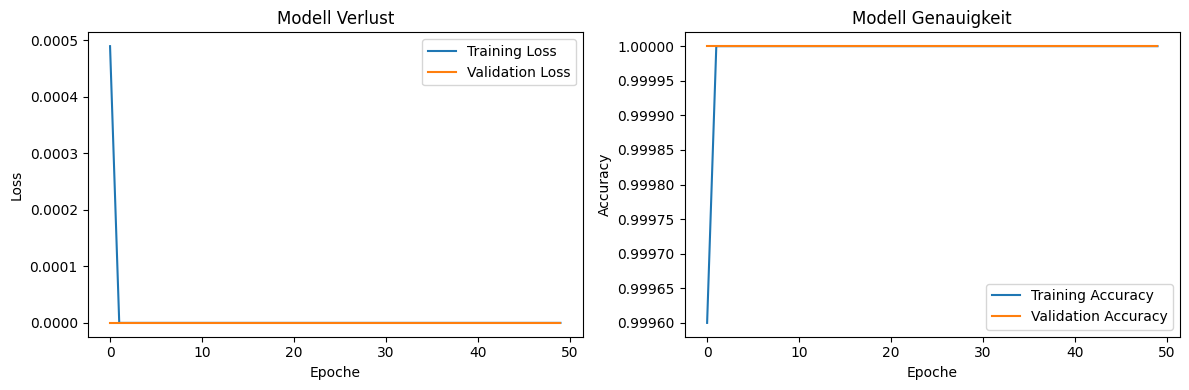

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

# Verlust
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modell Verlust')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Genauigkeit
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modell Genauigkeit')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

def evaluate_model(model, generator):
    y_true = []
    y_pred_prob = []
    
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = model.predict(X_batch)
        y_true.extend(y_batch)
        y_pred_prob.extend(preds.flatten())
    
    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, target_names=["Andere Nutzer", "Beispielnutzer"], labels=[0, 1], zero_division=0)
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    return conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred, y_pred_prob

print("Starte Evaluation des Modells auf Testdaten...")
conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred, y_pred_prob = evaluate_model(model, test_generator)

print("\nKonfusionsmatrix:")
print(conf_matrix)
print("\nKlassifikationsbericht:")
print(class_report)

Starte Evaluation des Modells auf Testdaten...
1/1 [==============================] - 0s 9ms/step


1/1 [==============================] - 0s 24ms/step

Konfusionsmatrix:
[[15000]]

Klassifikationsbericht:
                precision    recall  f1-score   support

 Andere Nutzer       1.00      1.00      1.00     15000
Beispielnutzer       0.00      0.00      0.00         0

     micro avg       1.00      1.00      1.00     15000
     macro avg       0.50      0.50      0.50     15000
  weighted avg       1.00      1.00      1.00     15000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_ranking.py:1133: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


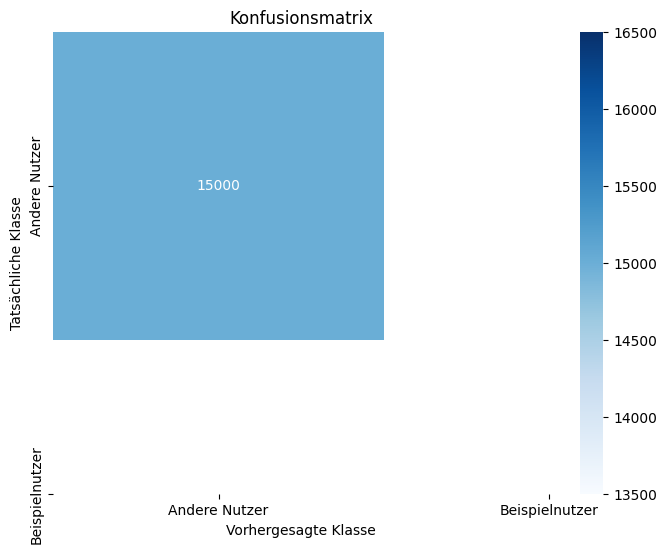

In [ ]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Andere Nutzer", "Beispielnutzer"],
            yticklabels=["Andere Nutzer", "Beispielnutzer"])
plt.title('Konfusionsmatrix')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.show()

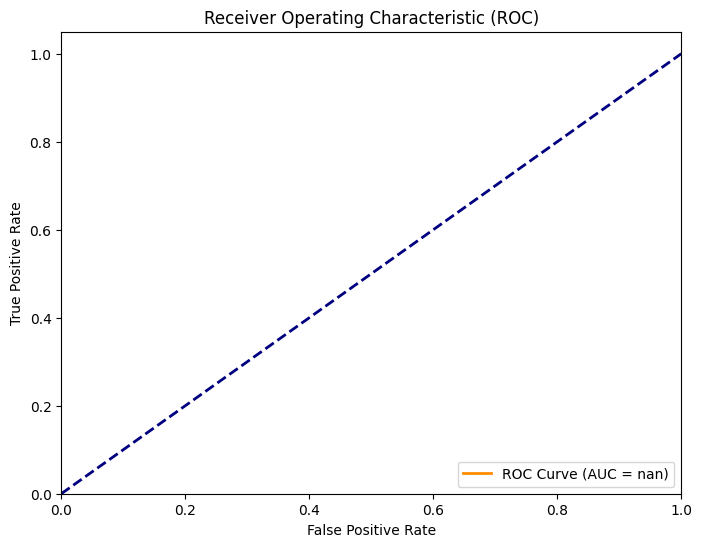

In [ ]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [ ]:
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]
false_positive_samples = test_df.iloc[false_positives].copy()
false_positive_samples['Vorhersage_Wahrscheinlichkeit'] = y_pred_prob[false_positives]

fp_per_user = false_positive_samples['username'].value_counts()

plt.figure(figsize=(10, 6))
sns.barplot(x=fp_per_user.index, y=fp_per_user.values, palette='Reds_r')
plt.xlabel('Nutzer', fontsize=14)
plt.ylabel('Anzahl der False Positives', fontsize=14)
plt.title('Anzahl der False Positives pro Nutzer', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

NameError: name 'test_df' is not defined

: 

: 

In [ ]:
results_df = test_df.copy()
results_df['y_true'] = y_true
results_df['y_pred_prob'] = y_pred_prob
results_df['y_pred'] = y_pred

results_df['Fehler'] = np.where(
    (results_df['y_pred'] == 1) & (results_df['y_true'] == 0), 'False Positive',
    np.where(
        (results_df['y_pred'] == 0) & (results_df['y_true'] == 1), 'False Negative',
        'Korrekt'
    )
)

selected_users = results_df['username'].unique()[:4]

plt.figure(figsize=(15, 8))

for user in selected_users:
    user_data = results_df[results_df['username'] == user]
    plt.plot(
        np.arange(len(user_data)),
        user_data['y_pred_prob'],
        label=f'Nutzer: {user}'
    )

plt.xlabel('Samples', fontsize=14)
plt.ylabel('Vorhersagewahrscheinlichkeit', fontsize=14)
plt.title('Modellkonfidenz pro Nutzer', fontsize=16)
plt.legend()
plt.show()

NameError: name 'test_df' is not defined

## Evaluation 3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

# Funktion zur Evaluation des Modells gegen andere Nutzer
def evaluate_against_other_users(model, user_generators, example_user_id):
    results = {}
    
    for user_id, (train_gen, val_gen, test_gen) in user_generators.items():
        if user_id == example_user_id:
            continue
        
        print(f"Evaluierung des Modells gegen Benutzer {user_id}...")
        
        y_true = []
        y_pred_prob = []
        
        for i in range(len(test_gen)):
            X_batch, y_batch = test_gen[i]
            preds = model.predict(X_batch)
            y_true.extend(y_batch)
            y_pred_prob.extend(preds.flatten())
        
        y_true = np.array(y_true)
        y_pred_prob = np.array(y_pred_prob)
        y_pred = (y_pred_prob > 0.5).astype(int)
        
        conf_matrix = confusion_matrix(y_true, y_pred)
        class_report = classification_report(y_true, y_pred, target_names=["Andere Nutzer", "Beispielnutzer"])
        fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
        roc_auc = auc(fpr, tpr)
        
        results[user_id] = {
            'conf_matrix': conf_matrix,
            'class_report': class_report,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'y_true': y_true,
            'y_pred': y_pred,
            'y_pred_prob': y_pred_prob
        }
        
        print(f"Konfusionsmatrix für Benutzer {user_id}:")
        print(conf_matrix)
        print(f"Klassifikationsbericht für Benutzer {user_id}:")
        print(class_report)
    
    return results

# Beispielhafter Benutzer (Nutzer 1)
example_user_id = 'user_1'  # Passen Sie dies an Ihren spezifischen Benutzer an

# Evaluierung des Modells gegen andere Nutzer
evaluation_results = evaluate_against_other_users(model, user_generators, example_user_id)

# Visualisierung der Ergebnisse
for user_id, metrics in evaluation_results.items():
    conf_matrix = metrics['conf_matrix']
    fpr = metrics['fpr']
    tpr = metrics['tpr']
    roc_auc = metrics['roc_auc']
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
                xticklabels=["Andere Nutzer", "Beispielnutzer"],
                yticklabels=["Andere Nutzer", "Beispielnutzer"])
    plt.title(f'Konfusionsmatrix - Benutzer {user_id}')
    plt.xlabel('Vorhergesagte Klasse')
    plt.ylabel('Tatsächliche Klasse')
    plt.show()
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'Receiver Operating Characteristic (ROC) - Benutzer {user_id}')
    plt.legend(loc="lower right")
    plt.show()

Evaluierung des Modells gegen Benutzer benutzername_1...
1/1 [==============================] - 0s 9ms/step


ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

# Evaluation

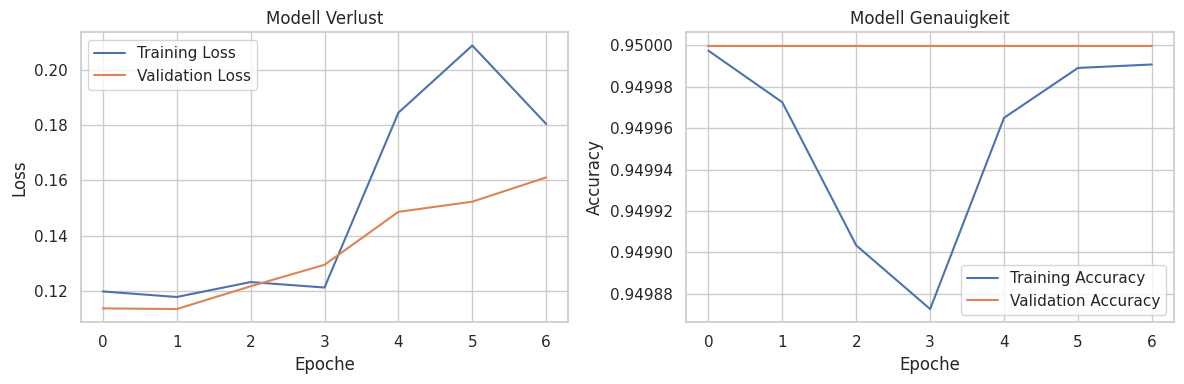

In [ ]:
# Zelle 8: Training Visualisierung

plt.figure(figsize=(12, 4))

# Verlust
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Modell Verlust')
plt.xlabel('Epoche')
plt.ylabel('Loss')
plt.legend()

# Genauigkeit
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Modell Genauigkeit')
plt.xlabel('Epoche')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# Zelle 9: Modell Evaluation

def evaluate_model(model, generator):
    y_true = []
    y_pred_prob = []
    
    # Predictions sammeln
    for i in range(len(generator)):
        X_batch, y_batch = generator[i]
        preds = model.predict(X_batch)
        y_true.extend(y_batch)
        y_pred_prob.extend(preds.flatten())
    
    y_true = np.array(y_true)
    y_pred_prob = np.array(y_pred_prob)
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    # Metriken berechnen
    conf_matrix = confusion_matrix(y_true, y_pred)
    class_report = classification_report(y_true, y_pred, target_names=["Andere Nutzer", "Beispielnutzer"])
    
    # ROC Kurve
    fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    
    return conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred, y_pred_prob

print("Starte Evaluation des Modells auf Testdaten...")
conf_matrix, class_report, fpr, tpr, roc_auc, y_true, y_pred, y_pred_prob = evaluate_model(model, test_generator)

print("\nKonfusionsmatrix:")
print(conf_matrix)
print("\nKlassifikationsbericht:")
print(class_report)

Starte Evaluation des Modells auf Testdaten...
1/1 [==============================] - 0s 13ms/step

Konfusionsmatrix:
[[380000      0]
 [ 20000      0]]

Klassifikationsbericht:
                precision    recall  f1-score   support

 Andere Nutzer       0.95      1.00      0.97    380000
Beispielnutzer       0.00      0.00      0.00     20000

      accuracy                           0.95    400000
     macro avg       0.47      0.50      0.49    400000
  weighted avg       0.90      0.95      0.93    400000



/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


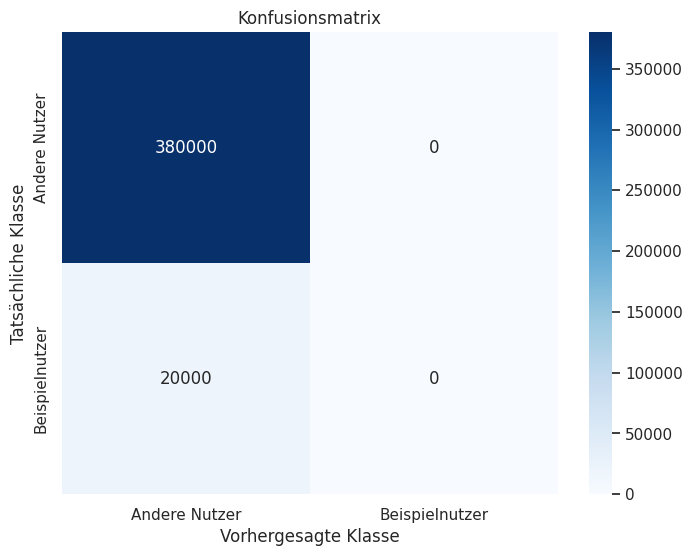

In [ ]:
# Zelle 10: Visualisierung der Konfusionsmatrix

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=["Andere Nutzer", "Beispielnutzer"],
            yticklabels=["Andere Nutzer", "Beispielnutzer"])
plt.title('Konfusionsmatrix')
plt.xlabel('Vorhergesagte Klasse')
plt.ylabel('Tatsächliche Klasse')
plt.show()

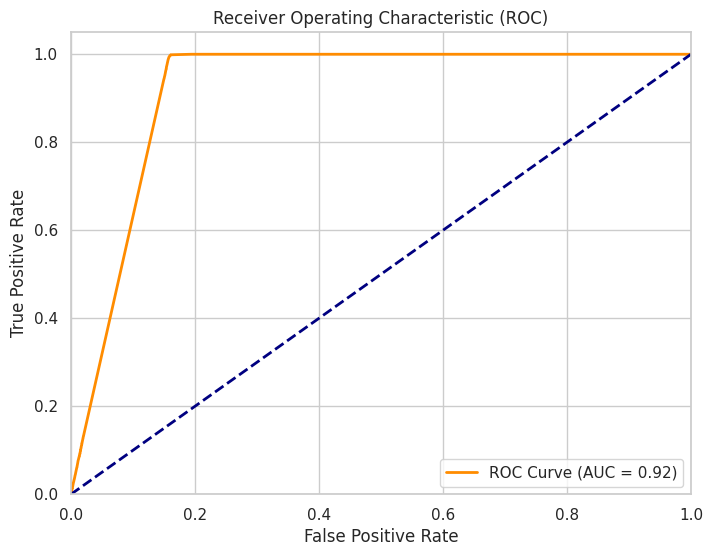

In [ ]:
# Zelle 11: ROC Kurve

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

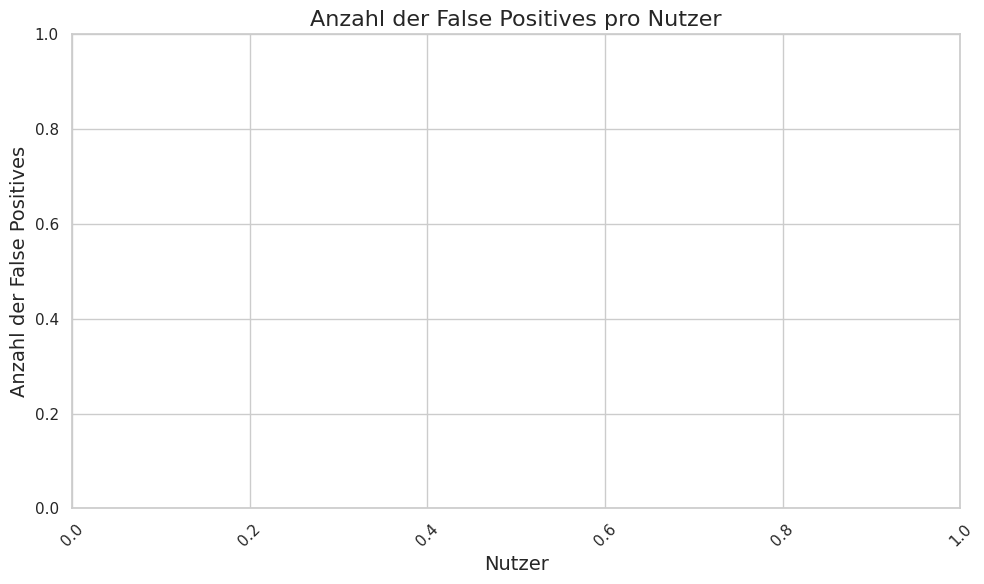

In [ ]:
# Zelle 12: False Positives analysieren und visualisieren

# Konvertiere y_true und y_pred in NumPy Arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_pred_prob = np.array(y_pred_prob)

# Identifiziere die False Positives
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]

# Erstelle DataFrame der False Positives
false_positive_samples = test_df.iloc[false_positives].copy()
false_positive_samples['Vorhersage_Wahrscheinlichkeit'] = y_pred_prob[false_positives]

# Anzahl der False Positives pro Nutzer
fp_per_user = false_positive_samples['username'].value_counts()

# Barplot erstellen
plt.figure(figsize=(10, 6))
sns.barplot(x=fp_per_user.index, y=fp_per_user.values, palette='Reds_r')
plt.xlabel('Nutzer', fontsize=14)
plt.ylabel('Anzahl der False Positives', fontsize=14)
plt.title('Anzahl der False Positives pro Nutzer', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

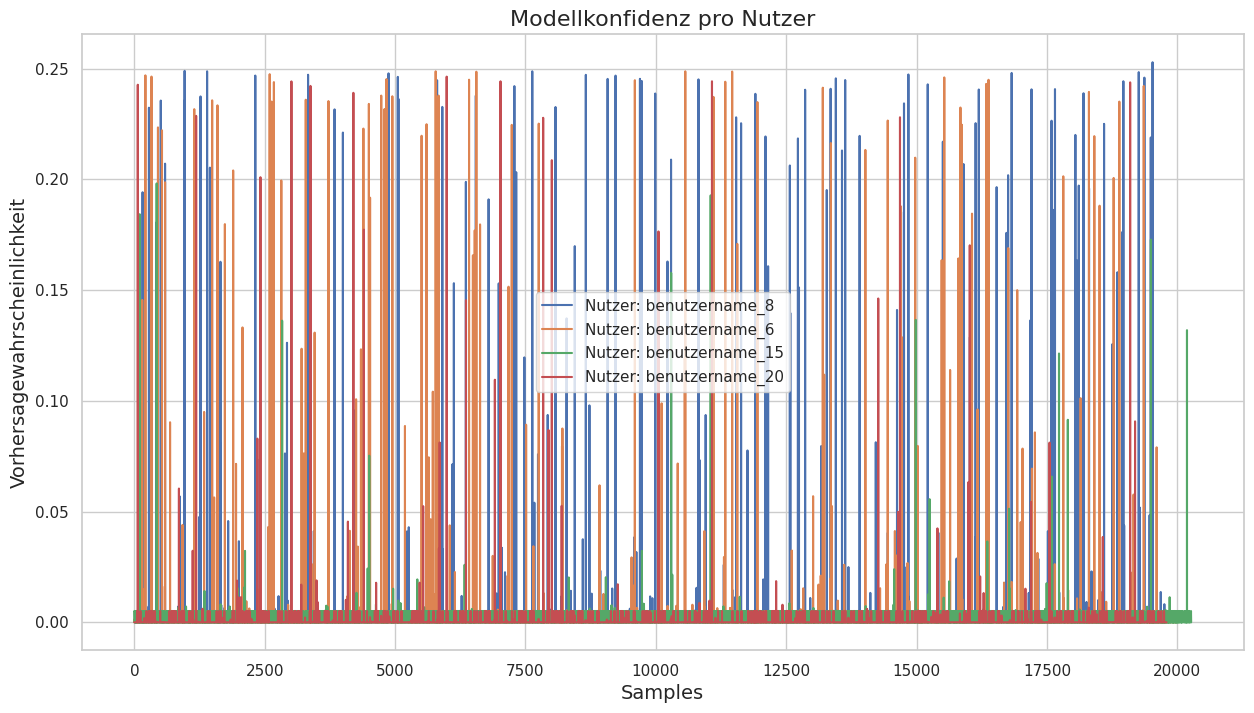

In [ ]:
# Zelle 13: Vorhersagewahrscheinlichkeiten visualisieren

# Erstelle ein DataFrame mit Vorhersagen und tatsächlichen Labels
results_df = test_df.copy()
results_df['y_true'] = y_true
results_df['y_pred_prob'] = y_pred_prob
results_df['y_pred'] = y_pred

# Markiere den Fehlertyp
results_df['Fehler'] = np.where(
    (results_df['y_pred'] == 1) & (results_df['y_true'] == 0), 'False Positive',
    np.where(
        (results_df['y_pred'] == 0) & (results_df['y_true'] == 1), 'False Negative',
        'Korrekt'
    )
)

# Line Plot der Vorhersagewahrscheinlichkeiten für eine Auswahl von Nutzern

# Wählen Sie eine Liste von Nutzern aus, die visualisiert werden sollen
selected_users = results_df['username'].unique()[:4]  # Beispiel: die ersten 4 Nutzer

plt.figure(figsize=(15, 8))

for user in selected_users:
    user_data = results_df[results_df['username'] == user]
    plt.plot(
        np.arange(len(user_data)),
        user_data['y_pred_prob'],
        label=f'Nutzer: {user}'
    )

plt.xlabel('Samples', fontsize=14)
plt.ylabel('Vorhersagewahrscheinlichkeit', fontsize=14)
plt.title('Modellkonfidenz pro Nutzer', fontsize=16)
plt.legend()
plt.show()